# Workshop on sensor processing using machine learning
Course: Intelligent Sensing and Sense Making

Website: https://www.iss.nus.edu.sg/executive-education/course/detail/intelligent-sensing-and-sense--making/artificial-intelligence

Contact: Tian Jing

Email: tianjing@nus.edu.sg

**Objective**: In this workshop, we will perform anomaly detection using autoencoder as reconstruction model. The machine health monitoring dataset is provided at https://github.com/ClockworkBunny/MHMS_DEEPLEARNING


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
print("PyTorch version is", torch.__version__)
# Use GPU if available else revert to CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device being used:", device)


PyTorch version is 2.8.0
Device being used: cpu


In [2]:
# Grant access to google drive.
# Run this cell, then you’ll see a link, click on that link, allow access
# Copy the code that pops up, paste it in the box, hit Enter

from google.colab import drive
drive.mount('/content/gdrive')

# Change working directory to be current folder
# os.chdir('/content/gdrive/My Drive/Your Folder Name/Your sub Folder Name')
os.chdir('/content/gdrive/My Drive/ISSM/Day3')
!ls


Mounted at /content/gdrive
archive  data  ISSM_Day3_wk_anomaly_yourname.ipynb


#### LOAD DATA, Resulting shapes = (N_train, D) and (N_test, D)

In [3]:
# Load data
x_train_pd = pd.read_csv("Day3/data/machine_sensor_train.csv",header=None)
x_train = x_train_pd.values
x_test_pd = pd.read_csv("Day3/data/machine_sensor_test.csv",header=None)
x_test = x_test_pd.values

print('Train shape: ', x_train.shape, 'Test shape:', x_test.shape)

Train shape:  (600, 70) Test shape: (300, 70)


In [4]:
# Define the model

#this class would create custom object to wrap the numpy array
class myDataset(torch.utils.data.Dataset):
    def __init__(self, x_data):
        self.X = x_data
        self.num_samples = x_data.shape[0]

    def __getitem__(self, index):
        return self.X[index].astype('float32')

    def __len__(self):
        return self.num_samples

#Autoencoder model
#Encoder takes D and transforms ==> hidden_node with ReLU
#Decoder transforms hidden_node ==> D, linear output w/o reLU
class myAEModel(nn.Module):
    def __init__(self, input_node, hidden_node):
        super(myAEModel, self).__init__()
        self.fc1 = nn.Sequential(nn.Linear(input_node, hidden_node), nn.ReLU())
        self.fc2 = nn.Sequential(nn.Linear(hidden_node, input_node)) # Note that the input signal has a range [-1,1], so we cannot use ReLU in the last layer
        #although, a Tanh output would also be acceptable if inputs are scaled to [-1,1]

    def encode(self, x):
        z = self.fc1(x)
        return z

    def decode(self, x):
        z = self.fc2(x)
        return z

    # forward(x) = decode(encode(x))
    def forward(self, x):
        z = self.encode(x)
        z = self.decode(z)
        return z

In [8]:
batch_size = 24

#provides randomized mini-batches; stacks returned NumPy arrays into a float tensor automatically
train_dataloader = torch.utils.data.DataLoader(myDataset(x_train), shuffle=True, batch_size=batch_size)

# # # Check dimension of a batch of training data
result = next(iter(train_dataloader))
#print batch shape - (24, D) since batch_size=24
print(result.shape)

input_node = x_train.shape[1]
hidden_node = 10
model = myAEModel(input_node, hidden_node)

model.to(device)
criterion = nn.MSELoss() #reconstruction loss; lower MSE ==> better reconstruction expected on normal data
learning_rate = 1e-4
num_epoch = 20
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

# for every batch we do forward → MSE → backprop → step
for epoch in range(num_epoch):
    running_loss = 0.0
    for i, data in enumerate(train_dataloader):
        data = data.to(device)

        output = model(data)
        loss_mse = criterion(data, output)

        optimizer.zero_grad()
        loss_mse.backward()
        optimizer.step()

        running_loss += loss_mse.cpu().item()

    #print the running loss
    print("Epoch: %d, loss: %.4f" % (epoch+1, loss_mse.cpu().item()))
    #print epoch average:
    print("Epoch average loss:" + str(running_loss/len(train_dataloader)))

torch.Size([24, 70])
Epoch: 1, loss: 0.4649
Epoch average loss:0.4764562523365021
Epoch: 2, loss: 0.4460
Epoch average loss:0.4651812505722046
Epoch: 3, loss: 0.4477
Epoch average loss:0.45582693815231323
Epoch: 4, loss: 0.4032
Epoch average loss:0.4475941562652588
Epoch: 5, loss: 0.4650
Epoch average loss:0.4372406029701233
Epoch: 6, loss: 0.3773
Epoch average loss:0.42194082140922545
Epoch: 7, loss: 0.4230
Epoch average loss:0.4058670496940613
Epoch: 8, loss: 0.3784
Epoch average loss:0.3902803909778595
Epoch: 9, loss: 0.3737
Epoch average loss:0.3749370181560516
Epoch: 10, loss: 0.3332
Epoch average loss:0.3599647557735443
Epoch: 11, loss: 0.3233
Epoch average loss:0.34536797165870664
Epoch: 12, loss: 0.3363
Epoch average loss:0.3311308407783508
Epoch: 13, loss: 0.2960
Epoch average loss:0.31742520689964293
Epoch: 14, loss: 0.2926
Epoch average loss:0.3041939771175384
Epoch: 15, loss: 0.2817
Epoch average loss:0.291469908952713
Epoch: 16, loss: 0.2593
Epoch average loss:0.2792752885

In [10]:
# Select a test sample
sample_index = 0

# Step 1: Select the test sample (such as the 0-th sample)
test_data_orig = x_test[sample_index:sample_index+1,:]
test_data_orig = torch.from_numpy(test_data_orig.astype('float32'))

model.eval()
with torch.no_grad():

        test_data_orig = test_data_orig.to(device)
        output = model(test_data_orig)
        # computes row-wise L2; with a single row, it returns a tensor of length 1
        dist = F.pairwise_distance(test_data_orig, output) # shape [1]
        print('Dissimlarity: %.4f' % (dist.item()))

print('The reconstruction error is %.2f' % dist)


Dissimlarity: 4.9719
The reconstruction error is 4.97


In [9]:
dist

tensor([4.4636])

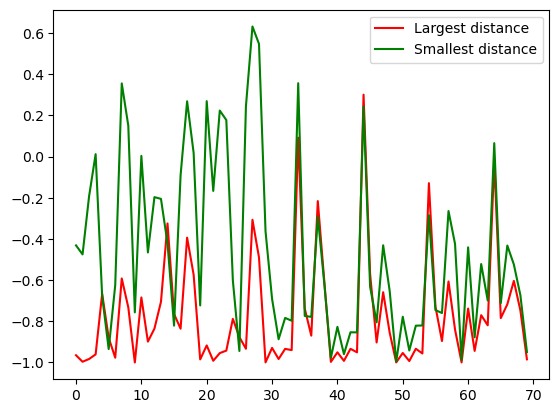

Minimum distance: 223-th sample, Error: 4.11
Maximum distance: 1-th sample, Error: 5.44


In [7]:
# Peform the test on x_test and determine the test data (row index) with the LARGEST reconstruction error based on the trained model
# Plot the data that is found by the model

dist_largest = 0
dist_smallest = 1e10
result_max = 0
result_min = 0

for sample_index in range (x_test.shape[0]):
    test_data_orig = x_test[sample_index:sample_index+1,:]

    # Step 1: Select the test sample (such as the 0-th sample)
    test_data_orig = x_test[sample_index:sample_index+1,:]
    test_data_orig = torch.from_numpy(test_data_orig.astype('float32'))

    model.eval()
    with torch.no_grad():

            test_data_orig = test_data_orig.to(device)
            output = model(test_data_orig)
            dist = F.pairwise_distance(test_data_orig, output)
            # print('Dissimlarity: %.4f' % (dist.item()))

    if (dist>dist_largest):
        dist_largest = dist
        result_max = sample_index
    if (dist<dist_smallest):
        dist_smallest = dist
        result_min = sample_index

plt.plot(x_test[result_max,:], 'r', label='Largest distance')
plt.plot(x_test[result_min,:], 'g', label='Smallest distance')
plt.legend()
plt.show()

print("Minimum distance: %d-th sample, Error: %.2f" % (result_min, dist_smallest))
print("Maximum distance: %d-th sample, Error: %.2f" % (result_max, dist_largest))

$\color{red}{\text{Discussions}}$

Q1: Recommend and describe a method to find a suitable threshold that is applied to the reconstruction error for anomaly detection.

Q2: If this generative autoencoder needs to be modified to be a contrastive autoencoder, suggest one method to construct the positive pair of samples and the negative pair of samples for this task.

In [8]:
# Provide your answers to Q1
#
#
tau = np.quantile(errors_val, 0.99)  # when FPR=α=1%
# Provide your answers to Q2
#
#


##### Answer 1
Quantile threshold on validation set to hit target false positive rate. IF AutoEncoder is trained on healthy data, its reconstruction errors on healthy samples should be small. So we choose a target FPR, and all healthy samples should be under the threshold T, with only the target FPR fraction exceeding it

##### Answer 2
Our goal here is to Learn an encoder that maps semantically similar signals close together while keeping dissimilar ones apart, in addition to reconstruction. Such a model that pushes apart different samples will yield more discriminative embeddings and sharper anomaly scores.

We can use augmentation-based positives i.e. two augmented views of same sample as positive (but realistic, like using time-crop/shift/warp, scaling, noise/jitter, random masking/dropout)

and we can use standard in-batch negatives -- all other augmented views in same minibatch.


**After you finish the workshop, rename and submit your .ipynb file.**